## Required packages before use in this order

> *pip install git+https://github.com/amr8004/ESPEI.git* <br>
<br>
> *pip install git+https://github.com/amr8004/pycalphad.git*

In [1]:
import numpy as np
import pandas as pd
import emcee
import matplotlib.pyplot as plt
import pycalphad.model as pype
from espei import pureElement as pe
from pycalphad.model import RWModelE,autoH,CSModelE,SRModelE,autoS,autoG, pe_dict, RTDB_globals, Define_Element
from espei.pureElement import imp_data_PE, log_probability, log_likelihood, Cp_fit, pe_inputJSON,pe_def_model, pe_iGuess
import json
import os

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pydantic\_migration.py:283: UserWarning: `pydantic:PyObject` has been moved to `pydantic.types:ImportString`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
os.chdir('C:/Users/xander/Documents/github_repositories/PureElement')
os.getcwd()

'C:\\Users\\xander\\Documents\\github_repositories\\PureElement'

In [3]:

element = 'Pt'
#csvName = r'C:/Users/xander/Documents/github_repositories/PureElement/CpCSV/{element}_CP_data.csv'
csvName = f'CpCSV/{element}_CP_data.csv'
jsonName = f'CpJson/{element}_CP.json'

# Read the CSV and add the data to a dictionary
df=pd.read_csv(csvName, header=[0,0])
header = df.columns.tolist()
data = {}
for col in header:
    column_values = df[col].values.flatten().tolist()
    data[col[0]] = column_values[::]

In [4]:
print(data.keys())
data['Temperature: K']

dict_keys(['Temperature: K', 'Heat capacity at constant pressure Cp: J/K/mol', 'Uncertainty', 'Pressure', 'Ref Temp', 'Data Set ID', 'State', 'Representation', 'Method', 'Description', 'Purity', 'Purity Units', 'Year'])


[76.46,
 81.4,
 91.7,
 98.85,
 201.5,
 206.1,
 17.5,
 19.46,
 21.78,
 24.34,
 26.75,
 30.26,
 35.42,
 42.4,
 50.5,
 57.6,
 96.1,
 101.9,
 108.0,
 114.3,
 121.0,
 198.2,
 203.1,
 208.3,
 373.15,
 473.15,
 573.15,
 673.15,
 773.15,
 873.15,
 973.15,
 1073.15,
 1173.15,
 1273.15,
 1373.15,
 1473.15,
 1576.15,
 1673.15,
 1773.15,
 1873.15,
 10.63,
 10.81,
 11.18,
 11.23,
 12.27,
 12.24,
 12.88,
 12.95,
 13.29,
 13.89,
 14.14,
 14.38,
 14.57,
 15.33,
 15.61,
 16.19,
 16.24,
 16.62,
 17.54,
 17.6,
 18.01,
 18.59,
 18.84,
 19.65,
 19.78,
 21.0,
 21.07,
 21.63,
 23.66,
 24.04,
 26.88,
 27.52,
 30.69,
 31.58,
 34.86,
 35.89,
 39.42,
 40.78,
 43.47,
 45.02,
 47.13,
 49.7,
 50.83,
 53.58,
 54.22,
 57.08,
 57.62,
 58.19,
 59.86,
 60.94,
 61.46,
 62.33,
 62.69,
 62.91,
 65.26,
 65.82,
 66.71,
 71.13,
 75.67,
 80.24,
 85.0,
 87.34,
 89.56,
 92.22,
 94.21,
 97.18,
 98.75,
 101.97,
 102.05,
 103.45,
 107.04,
 108.05,
 109.21,
 111.97,
 112.83,
 113.66,
 117.24,
 117.49,
 118.43,
 122.36,
 122.45,
 122

In [5]:
if 'Temperature: K' in data:
    data['Temp'] = data.pop('Temperature: K')
else:
    print("Key ['Temperature: K'] does not exist in the data dictionary.")


In [6]:
# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(jsonName), exist_ok=True)

# Open the file
with open(jsonName, 'w') as file:
    json.dump(data, file)

In [7]:
Define_Element([element.upper()])
data=imp_data_PE(jsonName)

In [8]:
# Load data from CSV
#data = pd.read_csv('sr_ipynb/Cr_Cp.txt', sep="\t")

# Extract columns
temp = data['Temp'].values
cp = data['Heat capacity at constant pressure Cp: J/K/mol'].values



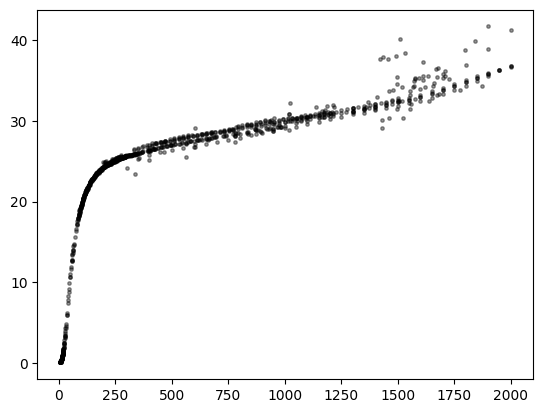

In [9]:
plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')

In [10]:
# Initial guess for parameters
initial_params = [230, 1e-3, 1e-6]  # You can adjust these initial guesses
initial_5params = [300, 1e-3, 0.01, 800, 300]
#initial_5params = [225, 1e-4, 1e-3, 150, 350]
nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [11]:
from espei.pureElement import log_probability

In [12]:
# Number of walkers and number of steps
nwalkers = 12
nsteps = 4000

model_flag='SRModelE'

# Set up the sampler
ndim = len(initial_5params)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_5params))
    for n,v in enumerate(initial_5params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
pos2 = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
# Run the MCMC sampling
sampler.run_mcmc(pos, nsteps, progress=True)


100%|██████████| 4000/4000 [02:15<00:00, 29.44it/s]


State([[1.81964994e+02 1.64210255e-03 7.11506825e-02 1.27011466e+04
  1.32982641e+04]
 [1.80509830e+02 1.82133886e-03 9.11744884e-02 1.69749567e+04
  1.75406159e+04]
 [1.80594004e+02 1.11181811e-03 5.84605796e-02 9.41913769e+03
  1.00315519e+04]
 [1.77594921e+02 1.60766977e-03 9.42048970e-02 1.65438053e+04
  1.71085702e+04]
 [1.77677394e+02 1.65950404e-03 9.60934188e-02 1.65601250e+04
  1.70922378e+04]
 [1.84930303e+02 8.47083104e-04 8.57334730e-02 1.35586827e+04
  1.42083054e+04]
 [1.82393584e+02 1.40140384e-03 4.09946173e-02 6.76866463e+03
  7.37382465e+03]
 [1.81857120e+02 1.05314831e-03 3.17388421e-02 4.46123282e+03
  5.02676892e+03]
 [1.80407928e+02 1.41693685e-03 8.74918174e-02 1.41659911e+04
  1.47038888e+04]
 [1.80170008e+02 1.40446993e-03 2.05697989e-02 2.86972099e+03
  3.41105343e+03]
 [1.81441205e+02 1.22598916e-03 6.12138630e-02 9.81136083e+03
  1.04052768e+04]
 [1.79575952e+02 1.30566302e-03 8.77943368e-02 1.47291377e+04
  1.53356462e+04]], log_prob=[-294.38443826 -293.970

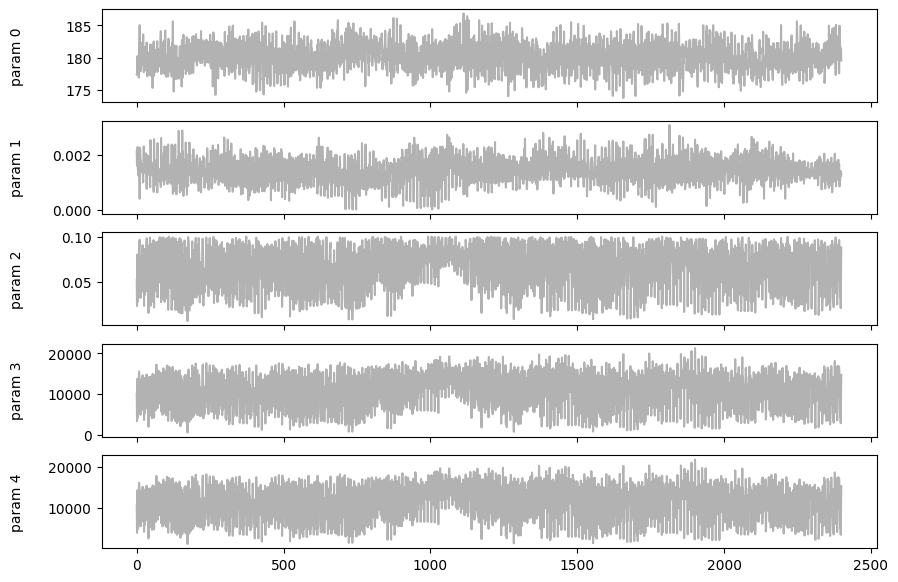

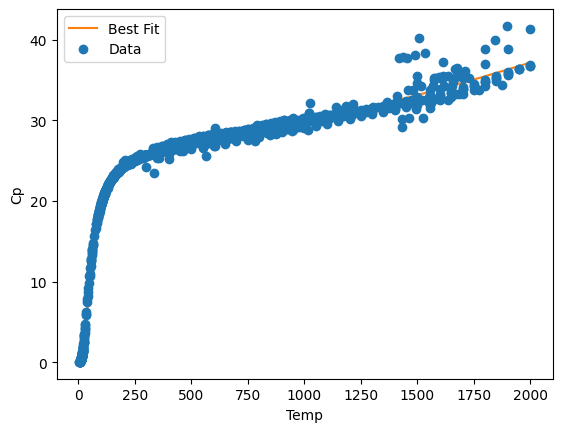

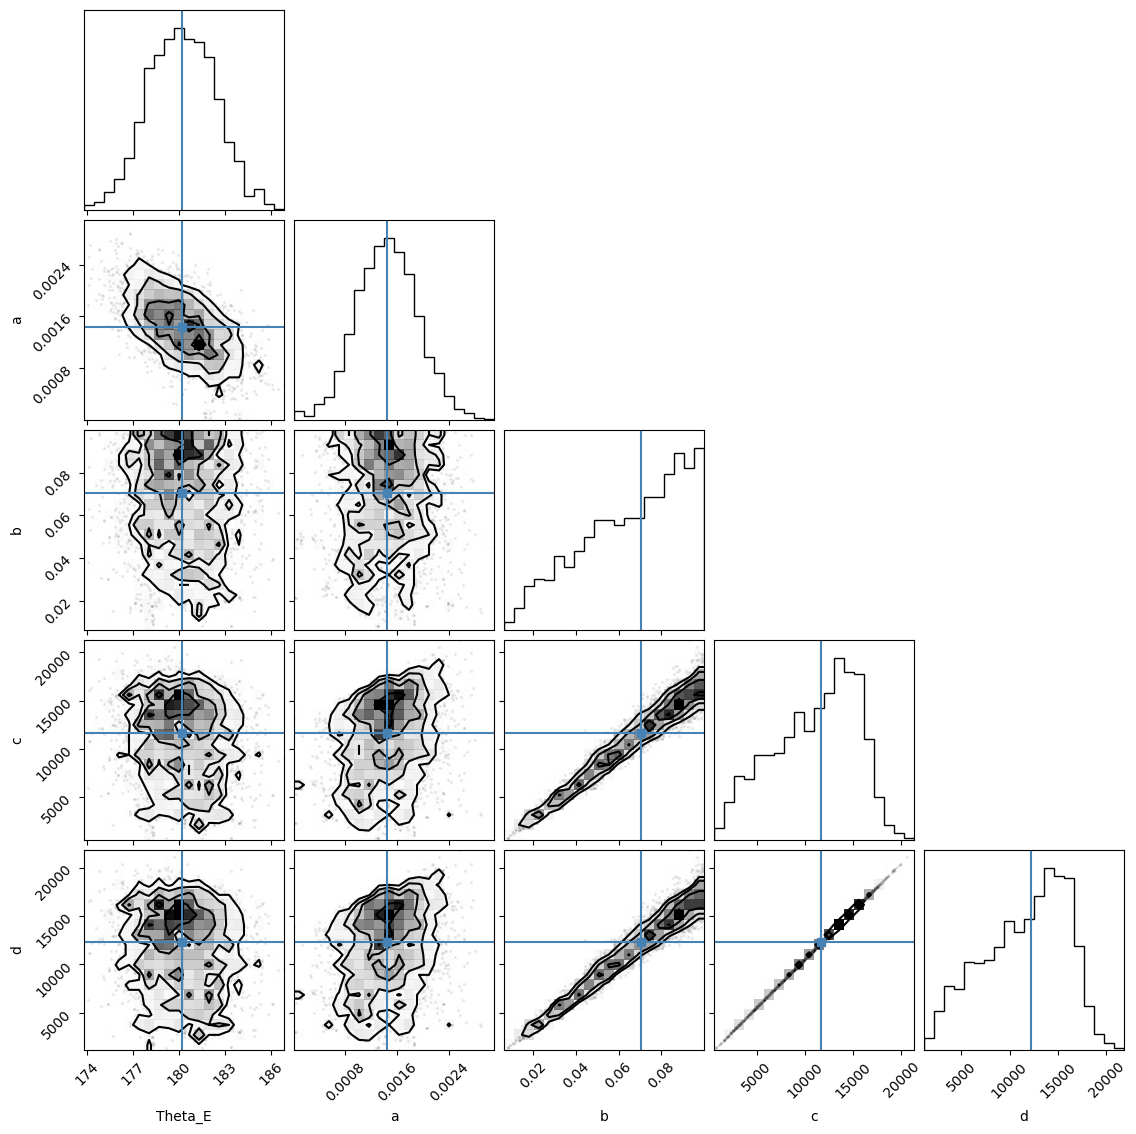

In [13]:
# Extract samples
samples = sampler.get_chain(flat=True, discard=1000, thin=15)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params = samples[np.argmax(log_prob)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples, labels=["Theta_E", "a", "b","c","d"], truths=best_params)
plt.show()


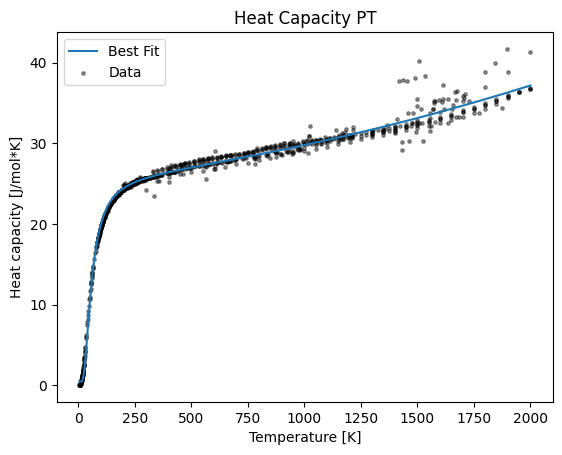

In [14]:
# Plot the best-fit curve with uncertainties
best_params = samples[np.argmax(log_prob)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')


plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

In [15]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([1.80158522e+02, 1.43539654e-03, 7.02355633e-02, 1.16943716e+04,
       1.22530158e+04])

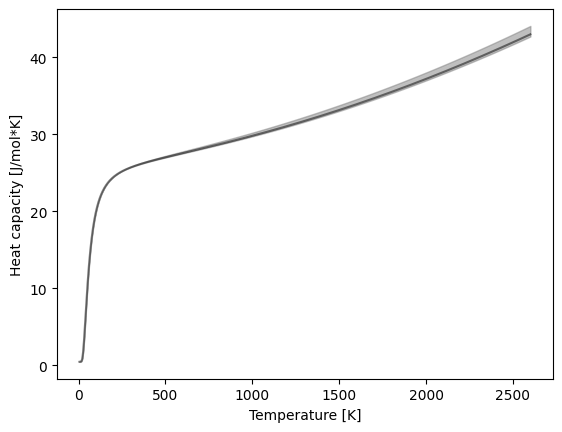

In [16]:
best_params = samples[np.argmax(log_prob)]
mean_params = np.mean(samples, axis=0)
rangeSR=np.percentile(samples, [40, 50, 84], axis=0)
T_plot = np.linspace(min(temp), max(temp)*1.3, 1000)

plt.figure()
#plt.errorbar(temp, cp, fmt='o', label='Data', color = 'grey', alpha = 0.1)
#plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Median', color = 'b')
#plt.plot(T_plot, SRModelE(T_plot, *mean_params), label='Mean', color = 'red')
plt.plot(T_plot, SRModelE(T_plot, *rangeSR[1]), label='50th', color = 'k', alpha = 0.5)
sixteenth=SRModelE(T_plot, *rangeSR[0])
eightyfourth=SRModelE(T_plot, *rangeSR[2])
plt.fill_between(T_plot, sixteenth, eightyfourth, color='grey', alpha=0.5)
plt.plot
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
#plt.legend()
plt.show()

In [17]:
s1 = np.std(samples[:,0], ddof=1)
s2 = np.std(samples[:,1], ddof=1)
s3 = np.std(samples[:,2], ddof=1)
s4 = np.std(samples[:,3], ddof=1)
s5 = np.std(samples[:,4], ddof=1)

In [18]:
print('Standard deviation of Theta_E:', s1)
print('Standard deviation of a:', s2)
print('Standard deviation of b:', s3)
print('Standard deviation of c:', s4)
print('Standard deviation of d:', s5)

Standard deviation of Theta_E: 2.1400248501571784
Standard deviation of a: 0.0004688196864092167
Standard deviation of b: 0.023537178594768657
Standard deviation of c: 4261.670530474756
Standard deviation of d: 4256.073685479571


In [19]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 1000

model_flag='CSModelE'

# Set up the sampler
ndim = len(initial_params)
sampler2 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler2.run_mcmc(pos, nsteps)


State([[1.75088677e+02 4.77039319e-03 2.11157787e-13]
 [1.73293512e+02 4.72657609e-03 2.16596499e-13]
 [1.73239815e+02 4.82489333e-03 2.01617113e-13]
 [1.72983588e+02 4.64195992e-03 2.02693891e-13]
 [1.74235253e+02 4.78772324e-03 2.13735092e-13]
 [1.74869865e+02 4.78660177e-03 1.84198753e-13]
 [1.74917338e+02 4.71664440e-03 2.06654299e-13]
 [1.74848494e+02 4.86220253e-03 2.08230074e-13]
 [1.73275661e+02 4.77757101e-03 2.04687155e-13]
 [1.72332263e+02 4.77582959e-03 1.91763488e-13]
 [1.73802582e+02 4.79271658e-03 1.90571568e-13]
 [1.72997398e+02 4.80736943e-03 2.09202653e-13]
 [1.74414433e+02 4.83043794e-03 2.07080728e-13]
 [1.71957877e+02 4.73635370e-03 1.93020681e-13]
 [1.73646482e+02 4.70036313e-03 2.13571226e-13]
 [1.73601358e+02 4.83740360e-03 1.85221475e-13]
 [1.74660486e+02 4.71537761e-03 2.18373617e-13]
 [1.69752065e+02 4.76845421e-03 2.07286853e-13]
 [1.75389488e+02 4.67950885e-03 2.46136021e-13]
 [1.71211488e+02 4.69929145e-03 2.06286034e-13]
 [1.74681041e+02 4.88560196e-03 1.

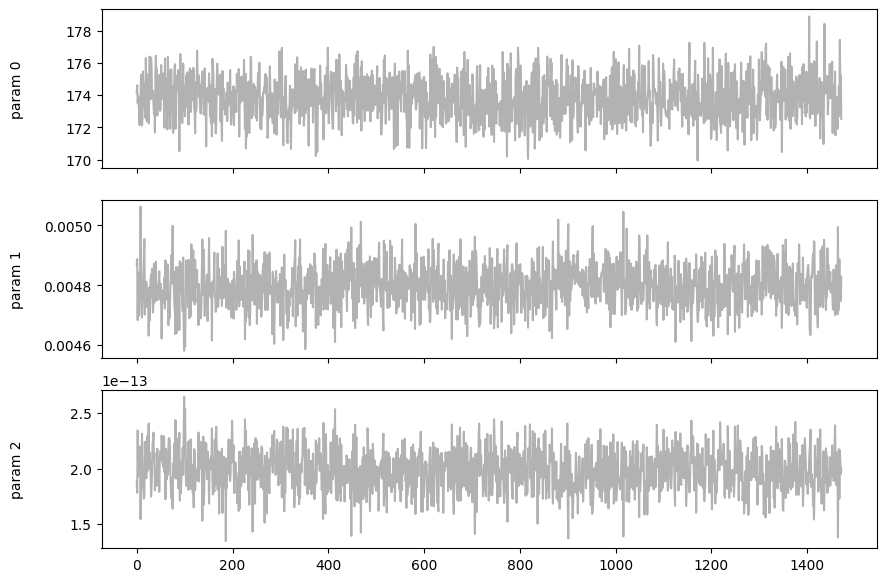

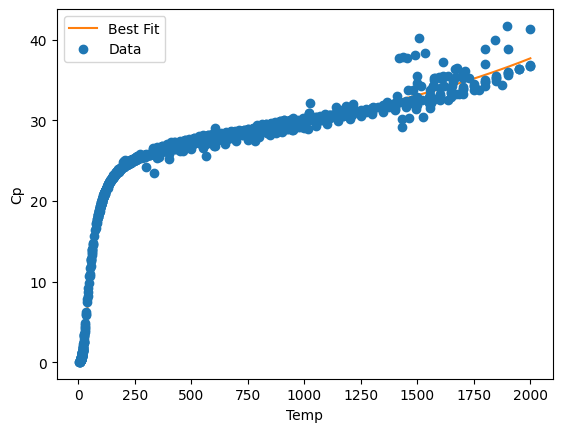

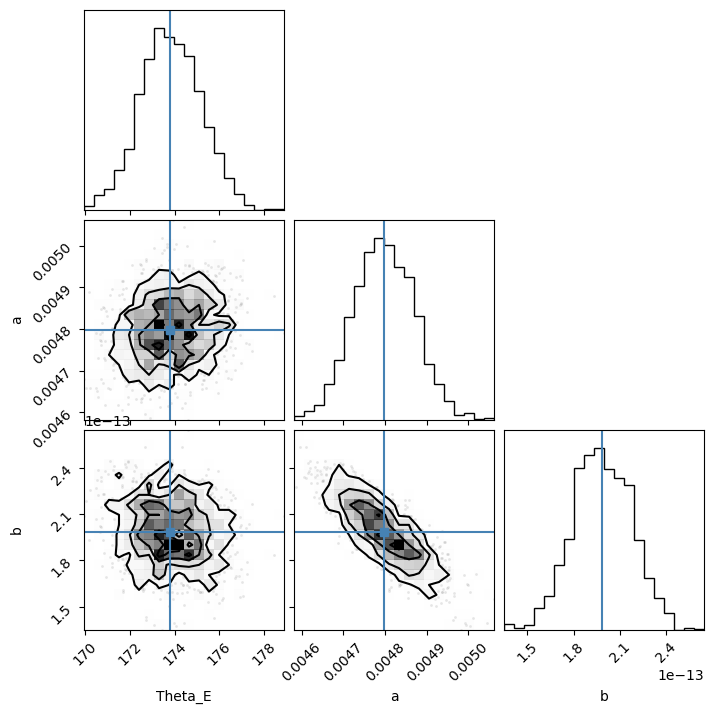

In [20]:
# Extract samples
samples2 = sampler2.get_chain(discard=300, thin=15, flat=True)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples2[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params2 = samples2[np.argmax(log_prob2)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples2, labels=["Theta_E", "a", "b"], truths=best_params2)
plt.show()


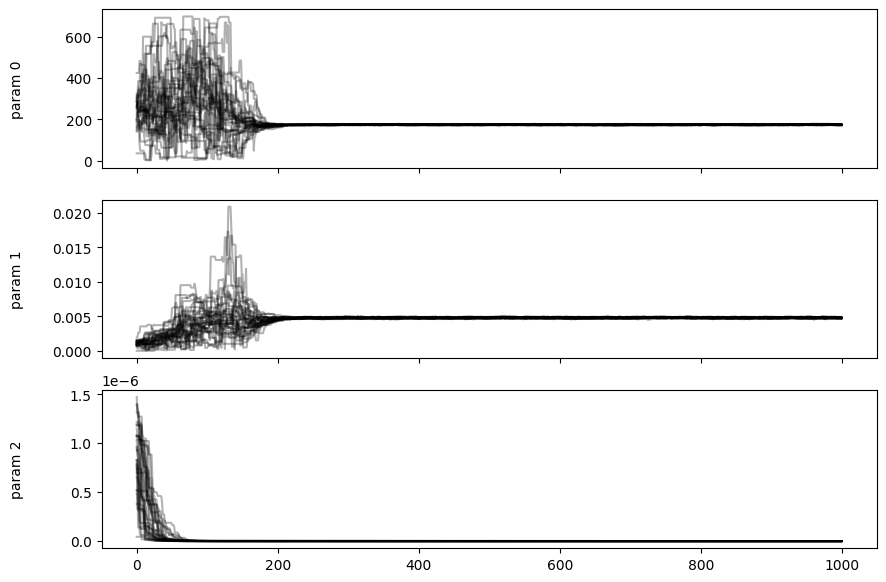

In [21]:
unflat2=sampler2.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [22]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.14f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params2

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([1.73811801e+02, 4.79709112e-03, 1.98158771e-13])

In [23]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 2000

model_flag='RWModelE'

# Set up the sampler
ndim = len(initial_params)
sampler3 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler3.run_mcmc(pos, nsteps)


State([[1.73946755e+02 4.10621774e-03 9.40486976e-07]
 [1.76142938e+02 3.95953447e-03 1.08544545e-06]
 [1.70578088e+02 4.06610634e-03 9.82900641e-07]
 [1.73592767e+02 4.15535226e-03 9.45998488e-07]
 [1.71030402e+02 4.03066516e-03 9.78985158e-07]
 [1.71104107e+02 3.87907272e-03 1.15691029e-06]
 [1.72150726e+02 4.10130883e-03 9.70594665e-07]
 [1.71527160e+02 3.95103100e-03 1.11561368e-06]
 [1.73637197e+02 4.28685472e-03 8.68029825e-07]
 [1.70328483e+02 3.94400047e-03 1.12921252e-06]
 [1.72203140e+02 3.90323911e-03 1.14206375e-06]
 [1.73310732e+02 4.30025261e-03 8.56011601e-07]
 [1.73356093e+02 4.13352300e-03 9.18279459e-07]
 [1.68684102e+02 4.10439734e-03 9.56729425e-07]
 [1.70558577e+02 4.26840803e-03 8.50079013e-07]
 [1.73873231e+02 4.21278582e-03 8.52609282e-07]
 [1.75098593e+02 4.16416700e-03 9.73462831e-07]
 [1.72681018e+02 4.16704749e-03 9.52656000e-07]
 [1.73518414e+02 4.09668139e-03 9.77049858e-07]
 [1.73041275e+02 3.91596807e-03 1.10508326e-06]
 [1.73479639e+02 3.84316161e-03 1.

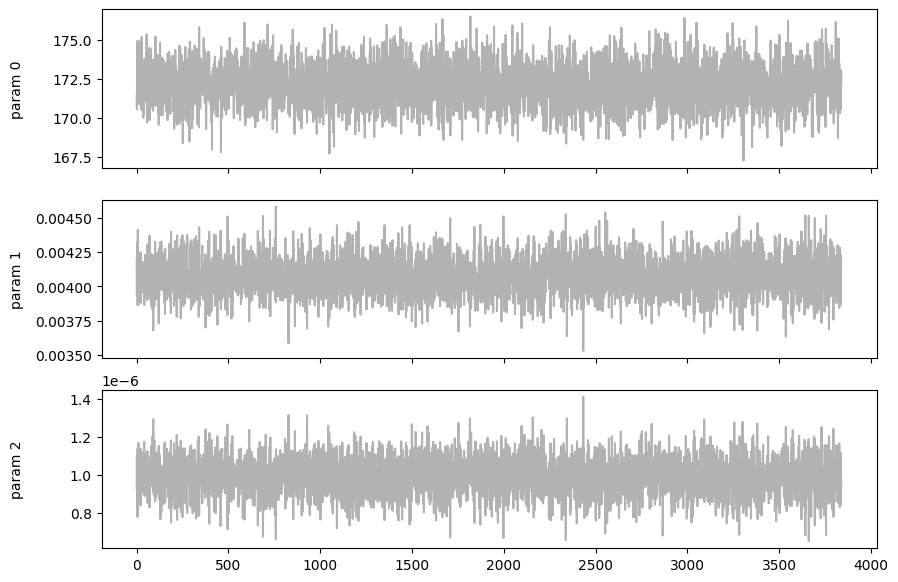

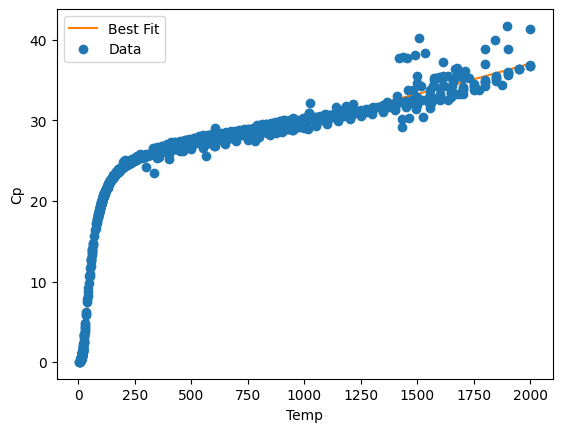

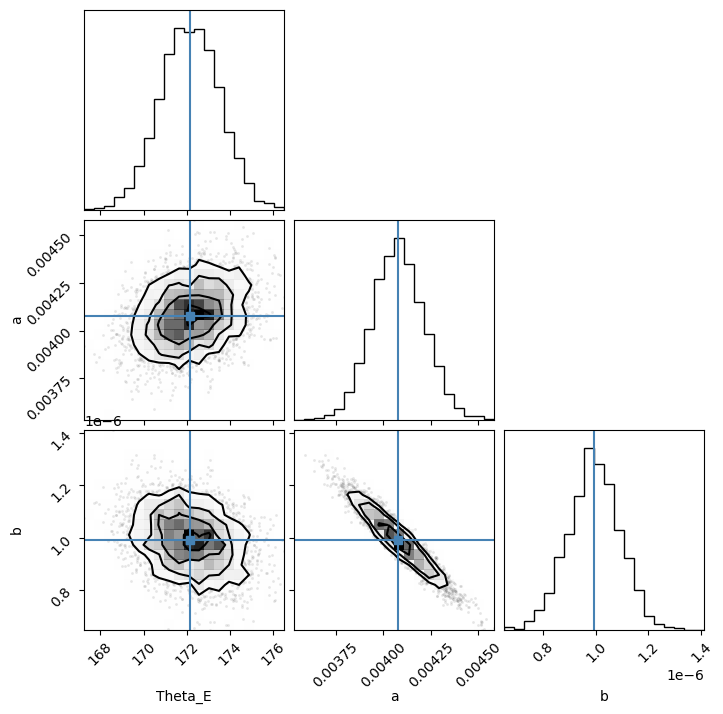

In [24]:
# Extract samples
samples3 = sampler3.get_chain(discard=200, thin=15, flat=True)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples3[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params3 = samples3[np.argmax(log_prob3)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples3, labels=["Theta_E", "a", "b"], truths=best_params3)
plt.show()


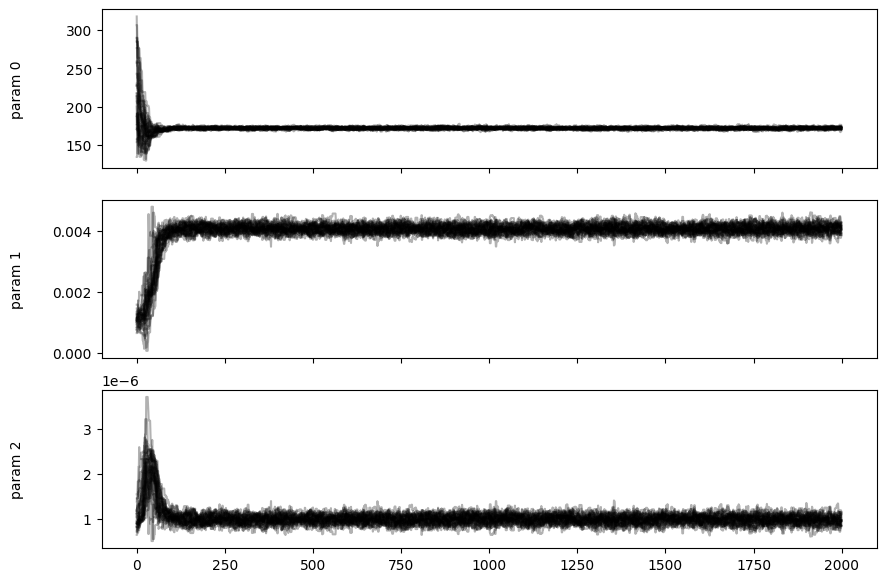

In [25]:
unflat2=sampler3.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [26]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples3[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params3)
for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params2)
for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[1.72144868e+02 4.07884002e-03 9.91920829e-07]


<IPython.core.display.Math object>

...

[1.73811801e+02 4.79709112e-03 1.98158771e-13]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[1.80158522e+02 1.43539654e-03 7.02355633e-02 1.16943716e+04
 1.22530158e+04]


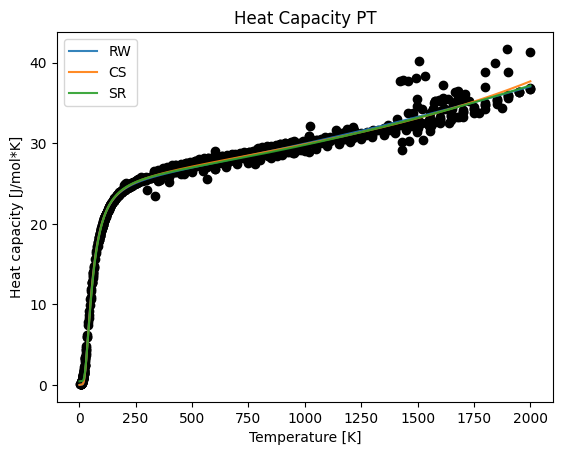

In [27]:
best_params3 = samples3[np.argmax(log_prob3)]
T_plot = np.linspace(1, max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k')#,s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.gca().set_aspect(30)
#plt.xlim(0,200)
#plt.ylim(0,50)
plt.show()

In [28]:
RW=(RWModelE(T_plot, *best_params3))*(6.022e23)*(1.380649e-23)
CS=(CSModelE(T_plot, *best_params2))*(6.022e23)*(1.380649e-23)
SR=(np.array(SRModelE(T_plot, *best_params)))*(6.022e23)*(1.380649e-23)
cp2=(cp)*(6.022e23)*(1.380649e-23)

In [29]:
print(RW[0],CS[0],SR[0])

0.03392081726292417 0.03988430251301355 3.7435948170454156


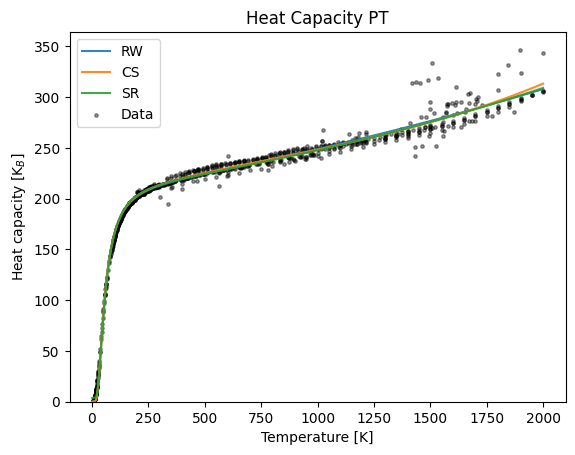

In [30]:
plt.figure()
plt.plot(T_plot, RW, label='RW', alpha=0.9)
plt.plot(T_plot, CS, label='CS', alpha=0.9)
plt.plot(T_plot, SR, label='SR', alpha=0.9)

plt.scatter(temp, cp2, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [K$_{B}$]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.xlim(300,900)
plt.ylim(0)
plt.show()

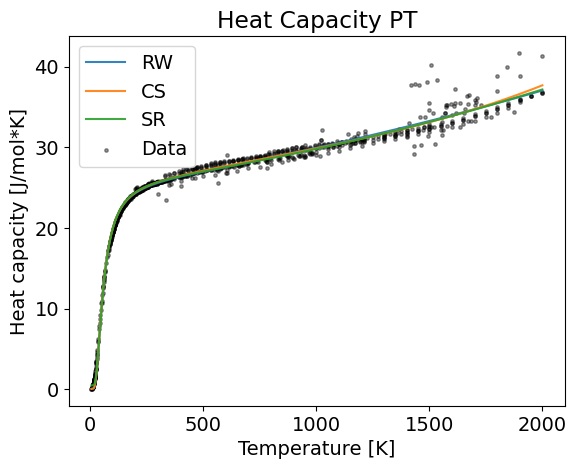

In [31]:
plt.rcParams.update({'font.size': 14})
best_params3 = samples3[np.argmax(log_prob3)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\io\tdb.py:925: UserWarning: The type definition character `I` was defined in the following phases: ['CBCC_A12', 'BCC_A2', 'FCC_A1', 'HCP_A3'], but no corresponding TYPE_DEFINITION line was found in the TDB.
  warnings.warn(f"The type definition character `{typechar}` was defined in the following phases: "


-190.05213373844083 <class 'numpy.ndarray'> 200
0.004079335977734574 <class 'numpy.ndarray'> 200
sr


c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1954: RuntimeWarning: invalid value encountered in log
  S = (alfa -g)**2.0*(3.0*k2/(8.0*g) - k2 *np.log(alfa-g)/(4*g))*x+(k1-k2*(alfa-g)/(2.0*g))*x**2+k2/(8.0*g)*x**3.0+k2/(4.0*g)*(alfa-g)**2.0*x*np.log(x)


Text(0.5, 1.0, 'Gibbs PT')

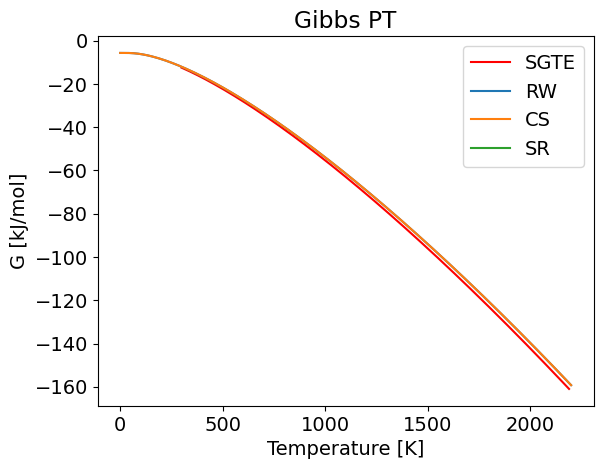

In [32]:
CSa=best_params2[1]
CSb=best_params2[2]
CSE=best_params2[0]

RWE = best_params3[0]
RWa=best_params3[1]
RWb=best_params3[2]

RTDB_globals['Te_final'] = best_params[0]
RTDB_globals['k1_final'] = best_params[1]
RTDB_globals['k2_final'] = best_params[2]
RTDB_globals['alfa_final'] = best_params[3]
RTDB_globals['g_final'] = best_params[4]
from pycalphad import Database, calculate, equilibrium, variables as v
db_sgte = Database('sgte-unary.tdb')
T_range = np.linspace(1,data.Temp.max()*1.1,num=200)
fcc_GM = calculate(db_sgte, [element.upper(), 'VA'], 'FCC_A1', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE', color = 'r')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
GSRtest=pype.GEin(RTDB_globals['Te_final'],T_range)+pype.GTBCM(T_range,RTDB_globals['k1_final'],RTDB_globals['k2_final'],RTDB_globals['alfa_final'],RTDB_globals['g_final'])#+pype.GibbsM_Bosse(T_range)
plt.plot(T_range,GSRtest/1000, label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("G [kJ/mol]")
plt.legend()
plt.title(f"Gibbs {RTDB_globals['element'][0]}")

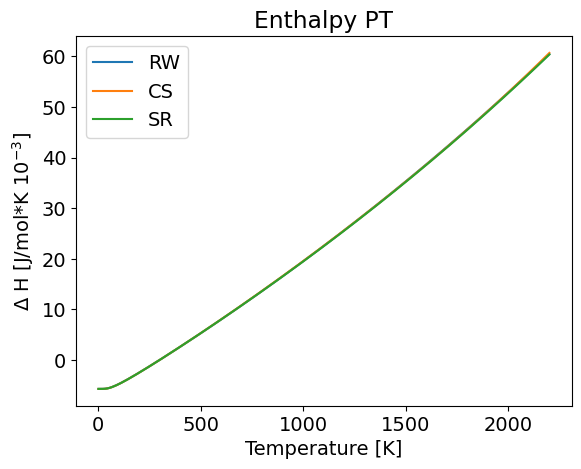

In [33]:
HCS298=pype.HTCSM(298.15,CSa,CSb)+pype.HEin(CSE,298.15)#+pype.HM(T_range)[29]
HSR298=pype.HTBCM(298.15,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],298.15)#+pype.HM(T_range)[149]
HRW298=pype.HTRWM(298.15,RWa,RWb)+pype.HEin(RWE,298.15)#+pype.HM(T_range)[149]
HCS=pype.HTCSM(T_range,CSa,CSb)+pype.HEin(CSE,T_range)#+pype.HM(T_range)
HCS2=HCS-HCS298
HSR2=pype.HTBCM(T_range,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],T_range)#+pype.HM(T_range)
HSR=HSR2-HSR298
HRW2=pype.HTRWM(T_range,RWa,RWb)+pype.HEin(RWE,T_range)#+pype.HM(T_range)
HRW=HRW2-HRW298
plt.plot(T_range,10**-3*HRW,label='RW')
plt.plot(T_range,10**-3*HCS2,label='CS')
plt.plot(T_range,10**-3*HSR,label='SR')
plt.xlabel("Temperature [K]")
plt.ylabel(r'$\Delta$ H [J/mol*K $10^{-3}$]')
plt.title("H_Ein+H_BCM-H298.15")
plt.title(f"Enthalpy {RTDB_globals['element'][0]}")
plt.legend()

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1935: RuntimeWarning: invalid value encountered in log
  Si = (alfa -g)**2.0*(3.0*k2/(8.0*g) - k2 *np.log(alfa-g)/(4*g))+(k1-k2*(alfa-g)/(2.0*g))*i+k2/(8.0*g)*i**2+k2/(4.0*g)*(alfa-g)**2.0*np.log(i)


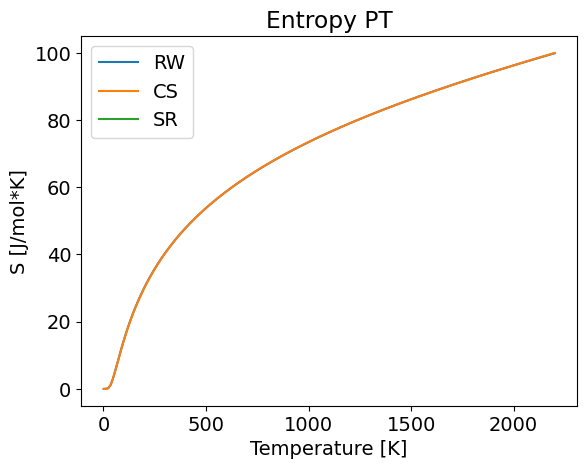

In [34]:
SE1=pype.SEin(RTDB_globals['Te_final'],T_range)
SBCM1=pype.STBCM(T_range, RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])
#Smag=pype.SM(T_range)
Scomb=SBCM1+SE1#+Smag
SRW=pype.STRWM(T_range,RWa,RWb)+pype.SEin(RWE,T_range)#+Smag
SCS=pype.STCSM(T_range,CSa,CSb)+pype.SEin(CSE,T_range)#+Smag
plt.plot(T_range,SRW,label = 'RW')
plt.plot(T_range,SCS,label = 'CS')
plt.plot(T_range,Scomb,label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("S [J/mol*K]")
plt.title(f"Entropy {RTDB_globals['element'][0]}")
plt.legend()

In [35]:
def PE_AICC(nparm, nobs,logLik,aicc_factor=None, kk=2):
    #print('CHECKPOINT AICC CALLED')
    k= nparm
    n = nobs
    AIC = -2 * logLik + kk *(k+1)
    print('k=',k,
    'n=',n)
    p=aicc_factor if aicc_factor is not None else 1.0
    pk = nparm*p
    aic = -2*logLik+2*(nparm+1)
    print('aic2:', aic)
    if pk >= (n-1.0):
        # Prevent the denominator of the proper mAICc from blowing up (pk = n - 1) or negative (pk > n - 1)
        correction = (2.0* p**2 * k**2 + 2.0 * pk) * (-n + pk + 3.0)
    else:
        correction = (2.0 * p**2 * k**2 + 2.0 * pk) / (n - pk - 1.0)
    aicc = aic+correction
    print('correction: ',correction)
    #print('CHECKPOINT AICC SOLVED')
    return aicc

nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [36]:
RW_logLik = log_likelihood(best_params3,temp,cp,'RWModelE')
AICC_RW=PE_AICC(nparm,nobs,RW_logLik)

CS_logLik = log_likelihood(best_params2,temp,cp,'CSModelE')
AICC_CS=PE_AICC(nparm,nobs,CS_logLik)

SR_logLik = log_likelihood(best_params,temp,cp,'SRModelE')
AICC_SR=PE_AICC(nparm5,nobs,SR_logLik)

k= 3 n= 987
aic2: 619.952323511273
correction:  0.024415055951169887
k= 3 n= 987
aic2: 611.3543488048397
correction:  0.024415055951169887
k= 5 n= 987
aic2: 600.1521707152758
correction:  0.06116207951070336


In [37]:
print('AICC_RW:', AICC_RW)
print('AICC_CS:', AICC_CS)
print('AICC_SR:', AICC_SR)

AICC_RW: 619.9767385672242
AICC_CS: 611.3787638607909
AICC_SR: 600.2133327947865


In [38]:
output_file='41_Elements/FCC/Results/'+element+'_output.json'
params={'CS':best_params2.tolist(),'RW':best_params3.tolist(),'SR':best_params.tolist(),'AICC_RW':AICC_RW,'AICC_CS':AICC_CS,'AICC_SR':AICC_SR}
with open(output_file, 'w') as f:
    json.dump(params, f, indent=4)